Loading the dataset

In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv("3_finance_loan_default.csv")
df.head()

,applicant_id,age,gender,marital_status,education_level,employment_type,years_employed,annual_income,monthly_income,income_stability_score,...,loan_to_value_ratio,savings_balance,checking_balance,investment_portfolio_value,monthly_expenses,has_direct_deposit,application_date,application_channel,relationship_tenure_years,defaulted
0,APP_00000001,40,Male,Single,High School,Unemployed,2,47091.0,3924.25,5,...,38.92,33611.07,1658.48,5023.84,2952.21,Yes,2023-09-29,Online,1,Yes
1,APP_00000002,25,Female,Single,Master,Full-time,5,106967.0,8913.92,7,...,67.32,2759.68,5001.68,15272.76,5318.34,Yes,2023-12-22,Online,0,No
2,APP_00000003,49,Female,Single,High School,Full-time,2,49860.0,4155.00,8,...,75.66,45724.84,8146.81,53611.86,1951.49,Yes,2023-12-03,Online,19,No
3,APP_00000004,37,Male,Married,High School,Full-time,5,61767.0,5147.25,9,...,84.35,22240.86,113.53,554.25,2845.05,No,2023-05-26,Online,0,No
4,APP_00000005,44,Male,Married,Bachelor,Part-time,2,99917.0,8326.42,6,...,60.51,NaN,5752.09,7490.29,NaN,Yes,2023-11-08,Branch,7,No


Clean the raw dataset with duplicate removal and date parsing.

In [37]:
df = df.drop_duplicates()
df['application_date'] = pd.to_datetime(df['application_date'], errors='coerce')
df['application_year'] = df['application_date'].dt.year
df['application_month'] = df['application_date'].dt.month
df['application_day'] = df['application_date'].dt.day

understanding the data


In [38]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   applicant_id                 15000 non-null  str           
 1   age                          15000 non-null  int64         
 2   gender                       15000 non-null  str           
 3   marital_status               15000 non-null  str           
 4   education_level              15000 non-null  str           
 5   employment_type              15000 non-null  str           
 6   years_employed               15000 non-null  int64         
 7   annual_income                15000 non-null  float64       
 8   monthly_income               15000 non-null  float64       
 9   income_stability_score       15000 non-null  int64         
 10  has_co_signer                15000 non-null  str           
 11  num_dependents               15000 non-null  int64  

applicant_id                     0
age                              0
gender                           0
marital_status                   0
education_level                  0
employment_type                  0
years_employed                   0
annual_income                    0
monthly_income                   0
income_stability_score           0
has_co_signer                    0
num_dependents                   0
credit_score                   600
credit_history_length_years      0
num_open_accounts                0
num_credit_inquiries_6m          0
debt_to_income_ratio             0
previous_defaults                0
bankruptcy_history               0
loan_amount                      0
loan_term_months                 0
loan_purpose                     0
interest_rate                    0
has_collateral                   0
loan_to_value_ratio              0
savings_balance                600
checking_balance                 0
investment_portfolio_value       0
monthly_expenses    

## HANDLING MISSING VALUES

In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
print('missing before fill:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].median())
df.loc[:, cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df_raw = df.copy()
print('missing after fill:')
print(df.isnull().sum()[df.isnull().sum() > 0])

missing before fill:
credit_score        600
savings_balance     600
monthly_expenses    600
dtype: int64
missing after fill:
Series([], dtype: int64)


## OUTLIER TREATMENT 

In [40]:

for col in num_cols:
    lower, upper = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)


## converting the binary columns (Yes/No -> 1/0)

In [41]:
binary_map = {"Yes": 1, "No": 0}

binary_cols = [
    "has_co_signer", "has_collateral", "has_direct_deposit",
    "bankruptcy_history", "defaulted"
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace(binary_map)
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].astype('Int64')

if 'defaulted' in df.columns:
    df['defaulted'] = df['defaulted'].astype('Int64')

if 'defaulted_flag' not in df.columns and 'defaulted' in df.columns:
    df['defaulted_flag'] = df['defaulted']

## ONE HOT ENCODE CATEGORICAL COLUMNS


In [42]:
ohe_cols = [
    "gender","marital_status","education_level",
    "employment_type","loan_purpose","application_channel"
]


for col in ["employment_type", "loan_purpose", "application_channel"]:
    df[f"{col}_orig"] = df[col]


df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

## CREATE IMPORTANT FEATURE BUCKETS
Credit Score Bucket  range


In [ ]:
bins = [0,580,670,740,800,900]
labels = ['Poor','Fair','Good','Very Good','Excellent']

df['credit_score_bucket'] = pd.cut(df['credit_score'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['credit_score_bucket'], drop_first=True)


Age Groups[Grouping from(20 to 100)]

In [44]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[20,30,45,60,100],
    labels=['Young','Mid-age','Mature','Senior']
)
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

## FEATURE ENGINEERING 

In [ ]:

if 'loan_to_income_ratio' not in df.columns:
    df['loan_to_income_ratio'] = df['loan_amount'] / df['annual_income']
if 'loan_term_years' not in df.columns:
    df['loan_term_years'] = df['loan_term_months'] / 12
if 'income_per_dependent' not in df.columns:
    df['income_per_dependent'] = df['annual_income'] / (1 + df['num_dependents'])


Exploratory Data Analysis and Hypothesis Testing



In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")


if 'defaulted_flag' not in df.columns:
    if df['defaulted'].dtype.kind in 'biu':
        df['defaulted_flag'] = df['defaulted']
    else:
        df['defaulted_flag'] = df['defaulted'].map({'Yes': 1, 'No': 0})

for col in ['credit_score', 'savings_balance', 'monthly_expenses']:
    df[col] = df[col].fillna(df[col].median())

if 'loan_to_income_ratio' not in df.columns:
    df['loan_to_income_ratio'] = df['loan_amount'] / df['annual_income']

df_eda = df_raw.copy()
if 'loan_to_income_ratio' not in df_eda.columns:
    df_eda['loan_to_income_ratio'] = df_eda['loan_amount'] / df_eda['annual_income']

outlier_cols = ['annual_income', 'loan_amount', 'loan_to_income_ratio', 'debt_to_income_ratio', 'credit_score']

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

capped_cols = []
for col in outlier_cols:
    if col in df_eda.columns:
        lower, upper = iqr_bounds(df_eda[col])
        df_eda[f'{col}_outlier'] = ~df_eda[col].between(lower, upper)
        df_eda[f'{col}_capped'] = np.clip(df_eda[col], lower, upper)
        capped_cols.append(f'{col}_capped')
        print(f"{col}: outliers={df_eda[f'{col}_outlier'].sum()} ({df_eda[f'{col}_outlier'].mean():.1%})")

print('\nCapped EDA summaries:')
print(df_eda[capped_cols].describe())

annual_income: outliers=653 (4.4%)
loan_amount: outliers=595 (4.0%)
loan_to_income_ratio: outliers=928 (6.2%)
debt_to_income_ratio: outliers=113 (0.8%)
credit_score: outliers=76 (0.5%)

Capped EDA summaries:
       annual_income_capped  loan_amount_capped  loan_to_income_ratio_capped  \
count          15000.000000        15000.000000                 15000.000000   
mean           69007.084975        24570.868950                     0.466643   
std            38379.899190        11644.644957                     0.323485   
min             3506.000000         2540.000000                     0.014860   
25%            39724.750000        15834.000000                     0.220561   
50%            60130.000000        22110.500000                     0.372263   
75%            89642.500000        30933.500000                     0.625979   
max           164519.125000        53582.750000                     1.234106   

       debt_to_income_ratio_capped  credit_score_capped  
count        

 Data Quality 
 


In [47]:
print('Total observations:', len(df))
print('Default rate:', df['defaulted_flag'].mean())
print('\nDefault counts by group:')
print(df['defaulted'].value_counts())


if 'employment_type_orig' not in df.columns or 'loan_purpose_orig' not in df.columns:
    raw = pd.read_csv('3_finance_loan_default.csv')[['applicant_id','employment_type','loan_purpose']]
    if 'applicant_id' in df.columns:
        df = df.drop(columns=[c for c in ['employment_type','loan_purpose'] if c in df.columns], errors='ignore')
        df = df.merge(raw.rename(columns={
            'employment_type': 'employment_type_orig',
            'loan_purpose': 'loan_purpose_orig'
        }), on='applicant_id', how='left')
    else:
        df['employment_type_orig'] = raw['employment_type']
        df['loan_purpose_orig'] = raw['loan_purpose']


print('\nDefault rate by employment type:')
print(df.groupby('employment_type_orig')['defaulted_flag'].mean().sort_values(ascending=False))

print('\nDefault rate by loan purpose:')
print(df.groupby('loan_purpose_orig')['defaulted_flag'].mean().sort_values(ascending=False).head(10))

Total observations: 15000
Default rate: 0.26006666666666667

Default counts by group:
defaulted
0    11099
1     3901
Name: count, dtype: Int64

Default rate by employment type:
employment_type_orig
Unemployed       0.483829
Full-time        0.250489
Self-employed       0.248
Retired          0.244444
Part-time        0.233117
Name: defaulted_flag, dtype: Float64

Default rate by loan purpose:
loan_purpose_orig
Personal              0.284065
Debt Consolidation    0.272687
Car                   0.265675
Medical               0.263069
Education             0.256177
Home                  0.251846
Business              0.249117
Name: defaulted_flag, dtype: Float64


 Feature distributions

Visual comparisons 


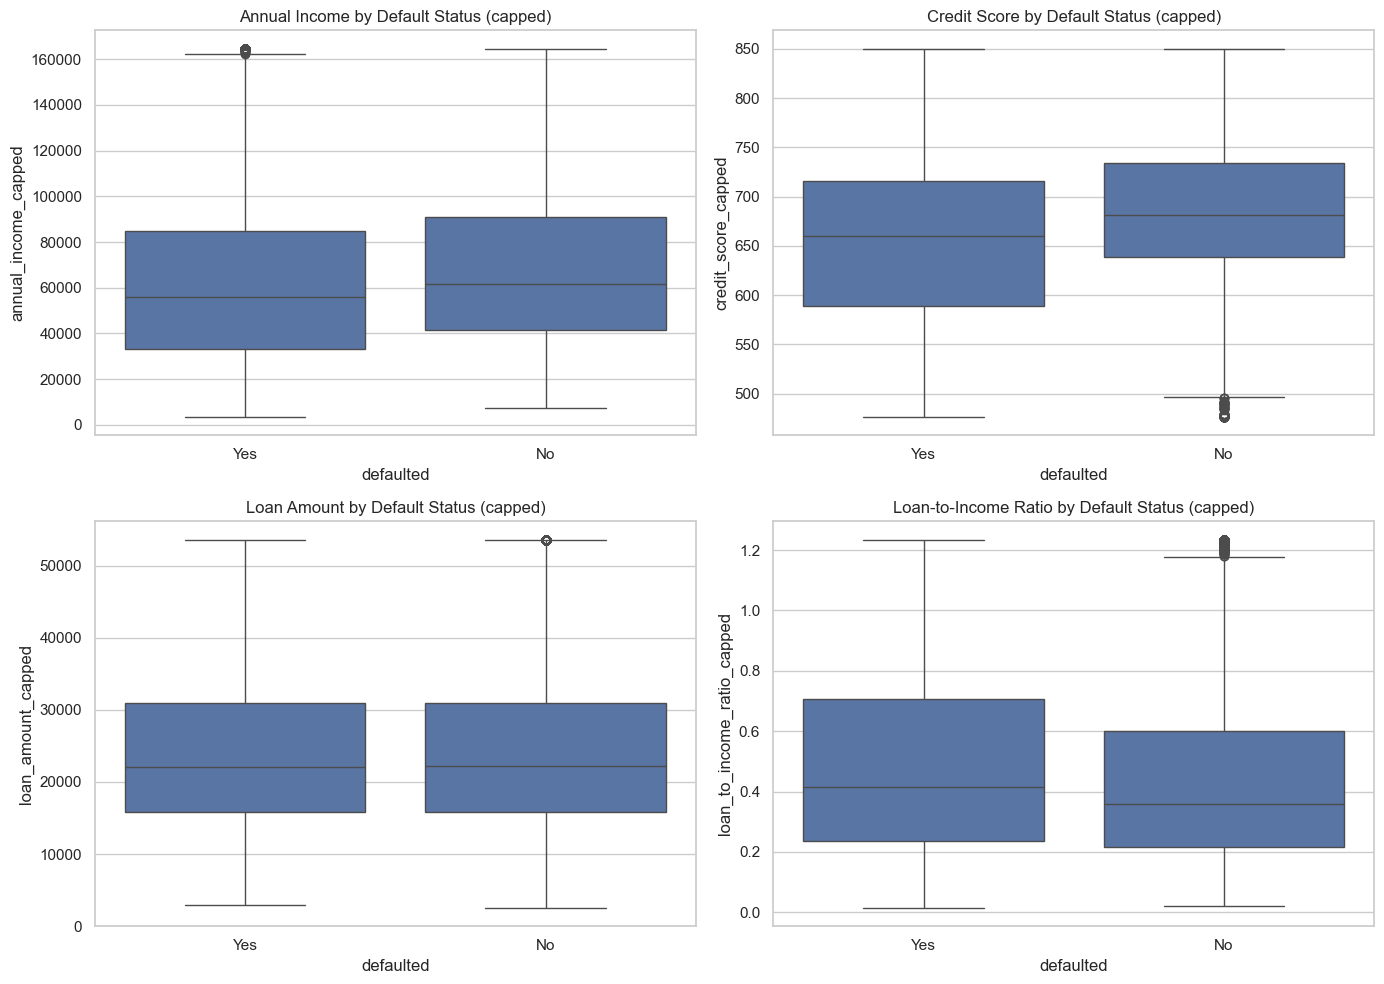

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='defaulted', y='annual_income_capped', data=df_eda, ax=axes[0,0])
axes[0,0].set_title('Annual Income by Default Status (capped)')

sns.boxplot(x='defaulted', y='credit_score_capped', data=df_eda, ax=axes[0,1])
axes[0,1].set_title('Credit Score by Default Status (capped)')

sns.boxplot(x='defaulted', y='loan_amount_capped', data=df_eda, ax=axes[1,0])
axes[1,0].set_title('Loan Amount by Default Status (capped)')

sns.boxplot(x='defaulted', y='loan_to_income_ratio_capped', data=df_eda, ax=axes[1,1])
axes[1,1].set_title('Loan-to-Income Ratio by Default Status (capped)')

plt.tight_layout()
plt.show()

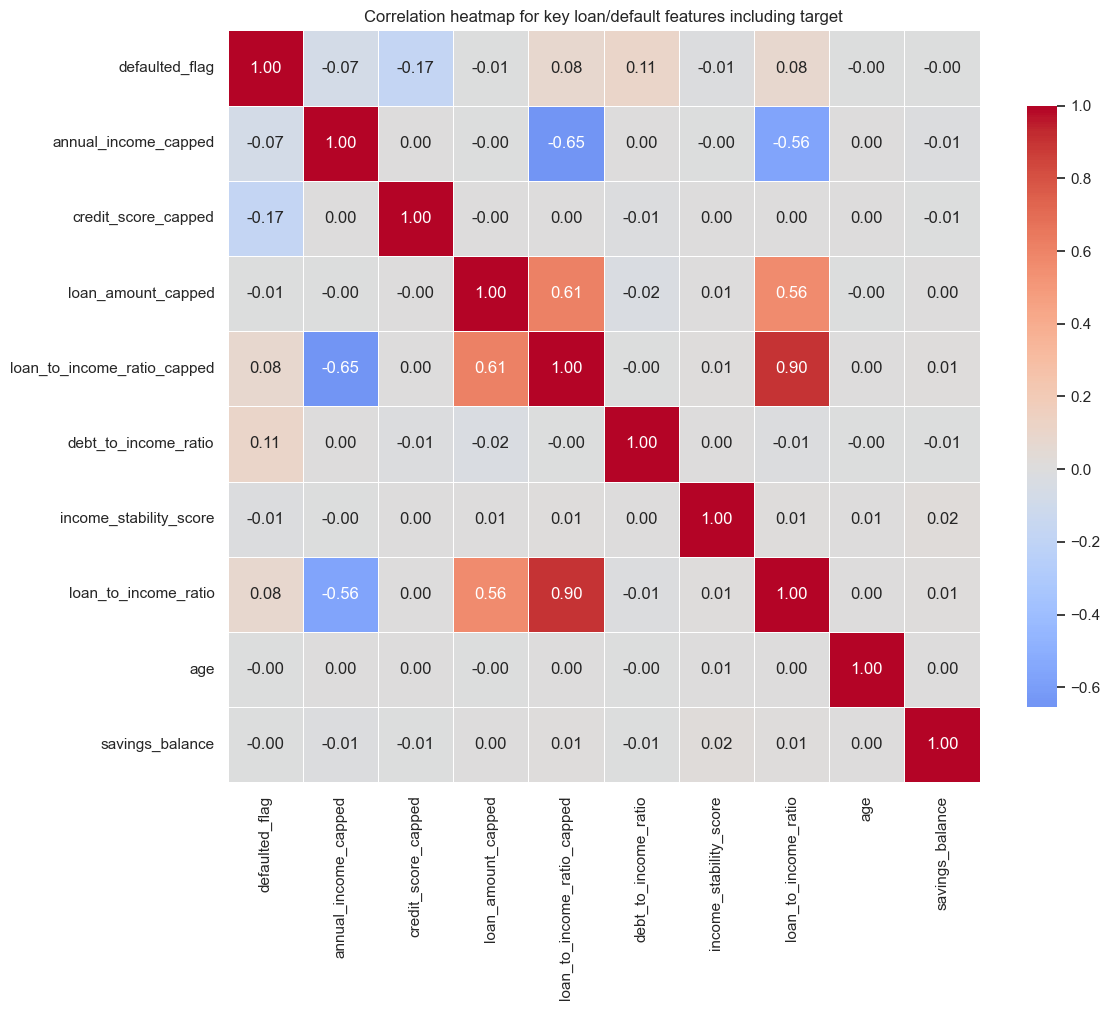

In [49]:
heatmap_cols = [
    'defaulted_flag', 'annual_income_capped', 'credit_score_capped',
    'loan_amount_capped', 'loan_to_income_ratio_capped', 'debt_to_income_ratio',
    'income_stability_score', 'loan_to_income_ratio', 'age', 'savings_balance'
]

if 'defaulted_flag' in df.columns:
    df_eda['defaulted_flag'] = df['defaulted_flag']

eda_cols = [col for col in heatmap_cols if col in df_eda.columns]
if len(eda_cols) == len(heatmap_cols):
    corr_df = df_eda[eda_cols]
else:
    df_cols = [col for col in heatmap_cols if col in df.columns]
    corr_df = df[df_cols]

fig, ax = plt.subplots(figsize=(12, 10))
corr = corr_df.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation heatmap for key loan/default features including target')
plt.tight_layout()
plt.show()

## Creating Extra Features

In [50]:

if 'expense_to_income_ratio' not in df.columns:
    df['expense_to_income_ratio'] = df['monthly_expenses'] / df['monthly_income']
if 'savings_to_income_ratio' not in df.columns:
    df['savings_to_income_ratio'] = df['savings_balance'] / df['annual_income']
if 'checking_to_income_ratio' not in df.columns:
    df['checking_to_income_ratio'] = df['checking_balance'] / df['annual_income']
if 'liquid_assets' not in df.columns:
    df['liquid_assets'] = df['savings_balance'].fillna(0) + df['checking_balance'].fillna(0) + df['investment_portfolio_value'].fillna(0)
if 'high_debt_to_income' not in df.columns:
    df['high_debt_to_income'] = (df['debt_to_income_ratio'] > 36).astype(int)

## testing the hypotheses identified from the EDA.

 Hypotheses Tested

H1: Income affects probability of default
- H0: There is no difference in annual income between defaulters and non-defaulters
- H1: Defaulters have significantly lower income

H2: Credit Score is associated with default likelihood
- H0: Mean credit score is the same between default groups
- H1: Mean credit score differs

H3: Loan amount and loan-to-value ratio influence default
- H0: Mean loan amount is the same between default groups
- H1: Defaulters have a different mean loan amount

H4: Employment type affects default rate
- H0: Employment type is independent of default outcome
- H1: Employment type is associated with default outcome

- H5: Income stability score differs between defaulters and non-defaulters
- H6: Debt-to-income ratio differs between groups
- H7: Previous defaults are more common among defaulters
- H8: Age differs between defaulters and non-defaulters

In [53]:
def run_ttest(series_a, series_b, label):
    stat, pvalue = stats.ttest_ind(series_a, series_b, equal_var=False, nan_policy='omit')
    print(f'{label}: t={stat:.3f}, p={pvalue:.4f}')
    print(f'  mean(defaulter) = {series_a.mean():.2f}, mean(non-defaulter) = {series_b.mean():.2f}\n')


defaulters = df[df['defaulted_flag'] == 1]
non_defaulters = df[df['defaulted_flag'] == 0]

run_ttest(defaulters['annual_income'], non_defaulters['annual_income'], 'Annual Income')
run_ttest(defaulters['credit_score'], non_defaulters['credit_score'], 'Credit Score')
run_ttest(defaulters['loan_amount'], non_defaulters['loan_amount'], 'Loan Amount')
run_ttest(defaulters['loan_to_value_ratio'], non_defaulters['loan_to_value_ratio'], 'Loan-to-Value Ratio')
run_ttest(defaulters['income_stability_score'], non_defaulters['income_stability_score'], 'Income Stability Score')
run_ttest(defaulters['debt_to_income_ratio'], non_defaulters['debt_to_income_ratio'], 'Debt-to-Income Ratio')
run_ttest(defaulters['previous_defaults'], non_defaulters['previous_defaults'], 'Previous Defaults')
run_ttest(defaulters['age'], non_defaulters['age'], 'Age')

# Chi-square test for employment type vs default
contingency = pd.crosstab(df['employment_type_orig'], df['defaulted_flag'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print('Employment Type vs Default (Chi-square)')
print(f'  chi2={chi2:.3f}, p={p:.4f}, dof={dof}')
print('\nContingency table:')
print(contingency)

Annual Income: t=-7.436, p=0.0000
  mean(defaulter) = 66223.72, mean(non-defaulter) = 72229.15

Credit Score: t=-19.831, p=0.0000
  mean(defaulter) = 656.56, mean(non-defaulter) = 686.16

Loan Amount: t=-0.643, p=0.5200
  mean(defaulter) = 24811.61, mean(non-defaulter) = 24961.83

Loan-to-Value Ratio: t=3.328, p=0.0009
  mean(defaulter) = 60.76, mean(non-defaulter) = 59.51

Income Stability Score: t=-1.419, p=0.1560
  mean(defaulter) = 6.93, mean(non-defaulter) = 6.98

Debt-to-Income Ratio: t=12.280, p=0.0000
  mean(defaulter) = 31.12, mean(non-defaulter) = 27.29

Previous Defaults: t=35.607, p=0.0000
  mean(defaulter) = 0.58, mean(non-defaulter) = 0.19

Age: t=-0.437, p=0.6618
  mean(defaulter) = 37.78, mean(non-defaulter) = 37.87

Employment Type vs Default (Chi-square)
  chi2=214.190, p=0.0000, dof=4

Contingency table:
defaulted_flag           0     1
employment_type_orig            
Full-time             7283  2434
Part-time             1181   359
Retired                544   176


## FINDINGS
Based on the statistical tests above, we can interpret which features are most strongly associated with default:
- If `annual_income` and `credit_score` have low p-values, then income and credit history are important predictors.
- A significant chi-square result for `employment_type` indicates that default rates vary across employment categories.
- The loan amount, loan-to-value ratio, and debt-to-income ratio help quantify loan risk.

This notebook provides a clean end-to-end workflow for understanding the dataset, engineering features, and validating hypotheses using statistical tests.

In [52]:
display(df)

,applicant_id,age,years_employed,annual_income,monthly_income,income_stability_score,has_co_signer,num_dependents,credit_score,credit_history_length_years,...,age_group_Mature,age_group_Senior,loan_to_income_ratio,loan_term_years,income_per_dependent,expense_to_income_ratio,savings_to_income_ratio,checking_to_income_ratio,liquid_assets,high_debt_to_income
0,APP_00000001,40,2,47091.0,3924.25,5,0,1,690.0,6,...,False,False,0.459642,10.0,23545.5,0.752299,0.713747,0.035219,40293.39,1
1,APP_00000002,25,5,106967.0,8913.92,7,0,1,648.0,1,...,False,False,0.400179,3.0,53483.5,0.596633,0.025799,0.046759,23034.12,0
2,APP_00000003,49,2,49860.0,4155.00,8,0,0,768.0,0,...,True,False,0.916045,7.0,49860.0,0.469673,0.917065,0.163394,107483.51,0
3,APP_00000004,37,5,61767.0,5147.25,9,1,1,850.0,1,...,False,False,0.566597,10.0,30883.5,0.552732,0.360077,0.001838,22908.64,0
4,APP_00000005,44,2,99917.0,8326.42,6,0,0,730.0,3,...,False,False,0.114015,7.0,99917.0,0.378794,0.105774,0.057569,23811.01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,APP_00014996,43,2,51335.0,4277.92,8,0,1,528.0,7,...,False,False,0.601870,6.0,25667.5,0.434728,0.466614,0.016607,28965.06,1
14996,APP_00014997,45,1,215134.0,17927.83,8,0,1,695.0,1,...,False,False,0.106245,5.0,107567.0,0.662630,0.037293,0.001678,15259.92,0
14997,APP_00014998,65,6,54784.0,4565.33,8,0,0,590.0,27,...,False,True,0.419958,3.0,54784.0,0.450660,0.188404,0.072784,21950.72,1
14998,APP_00014999,34,6,88945.0,7412.08,8,0,1,567.0,15,...,False,False,0.436877,6.0,44472.5,0.686400,0.154565,0.078980,45657.06,0
